In [47]:
import tensorflow as tf

In [48]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1 ,28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train = x_train / 255
x_test = x_test / 255


In [49]:
modelo = tf.keras.Sequential([
    tf.keras.Input(
        shape=(28,28,1)),
    tf.keras.layers.Conv2D(
            filters=5,
            kernel_size=3, 
            activation= 'relu'),
    tf.keras.layers.MaxPool2D(
            pool_size=2, strides=2, padding= 'valid'
        ),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation= 'relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
    
])

modelo.compile(
    optimizer= 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)



In [50]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights= True)

resultado = modelo.fit(x_train, y_train, epochs= 20, batch_size=32, validation_split=0.1, callbacks=[callback])

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9278 - loss: 0.2409 - val_accuracy: 0.9700 - val_loss: 0.1012
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9729 - loss: 0.0869 - val_accuracy: 0.9743 - val_loss: 0.0789
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0591 - val_accuracy: 0.9820 - val_loss: 0.0606
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9869 - loss: 0.0415 - val_accuracy: 0.9868 - val_loss: 0.0547
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9897 - loss: 0.0321 - val_accuracy: 0.9862 - val_loss: 0.0500
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9919 - loss: 0.0247 - val_accuracy: 0.9822 - val_loss: 0.0756
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9936 - loss: 0.0196 - val_accuracy: 0.9852 - val_loss: 0.0613
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9942 - loss: 0.0170 - 

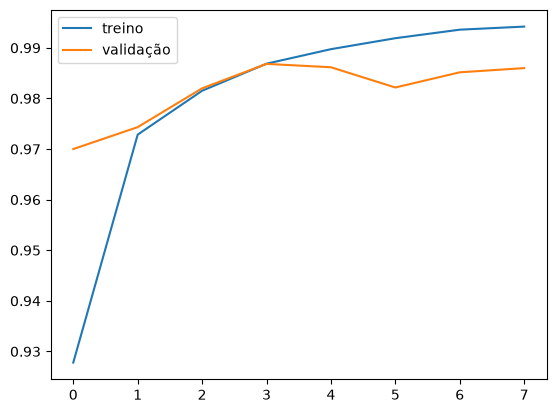

In [51]:
import matplotlib.pyplot as plt

plt.plot(resultado.history['accuracy'], label='treino')
plt.plot(resultado.history['val_accuracy'], label='validação')
plt.legend()
plt.show()

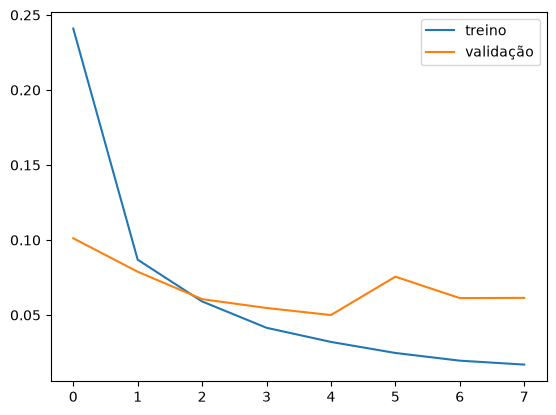

In [52]:
plt.plot(resultado.history['loss'], label = 'treino')
plt.plot(resultado.history['val_loss'], label='validação')
plt.legend()
plt.show()

In [53]:
metrics = modelo.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9817 - loss: 0.0571


In [ ]:
conv = tf.keras.layers.Conv2D(
    filters=2, kernel_size=(2,2), activation= 'relu', input_shape = (28,28,1)
)


maxpoll = tf.keras.layers.MaxPool2D(
    pool_size=2, strides=2, padding='valid'
)

In [56]:
test = x_train[:1]

result = conv(test)

In [57]:
result_maxpool = maxpoll(result)

In [58]:
print(result.shape)
print(result_maxpool.shape)

(1, 27, 27, 2)
(1, 13, 13, 2)
